<a href="https://colab.research.google.com/github/mariajosemuskusl/Integracion-de-Datos-y-Prospectiva/blob/main/Parcial_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Parcial 1**
## **Integración de Datos | Entidad Prestadora de Salud**

María José Muskus Londoño

**Caso de Estudio**

* Se analiza la información de varias sucursales de una entidad prestadora de salud. La entidad prestadora de salud quiere encontrar cuál sede tiene mayor afinidad con Sabaneta, que es la sucursal que se quiere cerrar, para después integrar pacientes utilizando los métodos de aceptación y rechazo.

**Objetivo del negocio**

* La entidad prestadora de salud busca mejorar la eficiencia en la prestación del servicio. Necesita cerrar la sucursal de Sabaneta y reubicar sus pacientes en otra sede que tenga un comportamiento parecido.

**Metodología**
* Teoría de la Credibilidad: permite determinar la afinidad entre bases de datos de acuerdo con sus medidas de tendencia central y dispersión.
* Métodos de Aceptación y Rechazo: agrupa una serie de métodos para la integración de datos basada en la estructura intrínseca de las variables de referencia utilizadas para la integración (Valor de Pertenencia, Aceptación/Rechazo).

La variable seleccionada para el análisis es 'BMI'

**0. Cargar las librerías de trabajo**

In [154]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**1. Clusterización estadística**

In [155]:
def caracterizacion(LDA, nombre=""):

  # Se organiza la gráfica de la distribución (solo un gráfico)
  fig, ax = plt.subplots(figsize=(7,4))

  ax.hist(LDA, bins=10, color='purple', edgecolor='black', alpha=0.8)
  ax.set_title(f"Distribución de BMI - {nombre}")
  ax.set_xlabel("BMI")
  ax.set_ylabel("Frecuencia")
  ax.grid(alpha=0.3)

  plt.tight_layout()
  plt.show()

  # Se procede con la caracterización de la variable
  np.set_printoptions(suppress=True)
  NI = 10
  counts, bin_edges = np.histogram(LDA, bins=NI)
  XC = (bin_edges[:-1] + bin_edges[1:]) / 2

  print("El número de datos por intervalo es:")
  print(counts)
  print("Los intervalos inferiores son:")
  print(bin_edges[:-1])
  print("Los intervalos superiores son:")
  print(bin_edges[1:])

  # Se configura la tabla de los datos
  Tabla = np.column_stack((bin_edges[:-1], bin_edges[1:], XC, counts))
  df = pd.DataFrame(Tabla, columns=['LI', 'LS', 'XC', 'ND'])

  # Se estiman las medidas estadísticas
  fr = counts / np.sum(counts)
  u = np.sum(XC * fr)
  sigma2 = np.sum(fr * (XC - u) ** 2)
  sigma = np.sqrt(sigma2)
  Cas = np.sum(fr * (XC - u) ** 3) / sigma ** 3
  Kur = (np.sum(fr * (XC - u) ** 4) / sigma ** 4) - 3

  print(f"\nMedia: {u:.4f}")
  print(f"Desviación estándar: {sigma:.4f}")
  print(f"Coeficiente de asimetría: {Cas:.4f}")
  print(f"Kurtosis: {Kur:.4f}")

  display(df)

  return u, sigma, Cas, Kur, df

**2. Cargar los archivos de trabajo**

In [156]:
# Cargar la base de datos
nxl = '/content/drive/MyDrive/University/Integración de Datos y Prospectiva/Parciales/3. Parcial - medical_attention_data.xlsx'

# Cargar las bases de datos de cada sucursal
XDB_Bello = pd.read_excel(nxl, sheet_name='Bello')
XDB_Medellin = pd.read_excel(nxl, sheet_name='Medellín')
XDB_Envigado = pd.read_excel(nxl, sheet_name='Envigado')
XDB_Caldas = pd.read_excel(nxl, sheet_name='Caldas')
XDB_Sabaneta = pd.read_excel(nxl, sheet_name='Sabaneta')
XDB_Itagui = pd.read_excel(nxl, sheet_name='Itagui')

# Se extrae la variable de referencia: BMI
LDA_Sabaneta = np.array(XDB_Sabaneta['BMI'])
LDA_Bello = np.array(XDB_Bello['BMI'])
LDA_Medellin = np.array(XDB_Medellin['BMI'])
LDA_Envigado = np.array(XDB_Envigado['BMI'])
LDA_Caldas = np.array(XDB_Caldas['BMI'])
LDA_Itagui = np.array(XDB_Itagui['BMI'])

print(f"Sabaneta: {len(LDA_Sabaneta)} pacientes")
print(f"Bello: {len(LDA_Bello)} pacientes")
print(f"Medellín: {len(LDA_Medellin)} pacientes")
print(f"Envigado: {len(LDA_Envigado)} pacientes")
print(f"Caldas: {len(LDA_Caldas)} pacientes")
print(f"Itagüí: {len(LDA_Itagui)} pacientes")

Sabaneta: 621 pacientes
Bello: 502 pacientes
Medellín: 895 pacientes
Envigado: 792 pacientes
Caldas: 909 pacientes
Itagüí: 684 pacientes


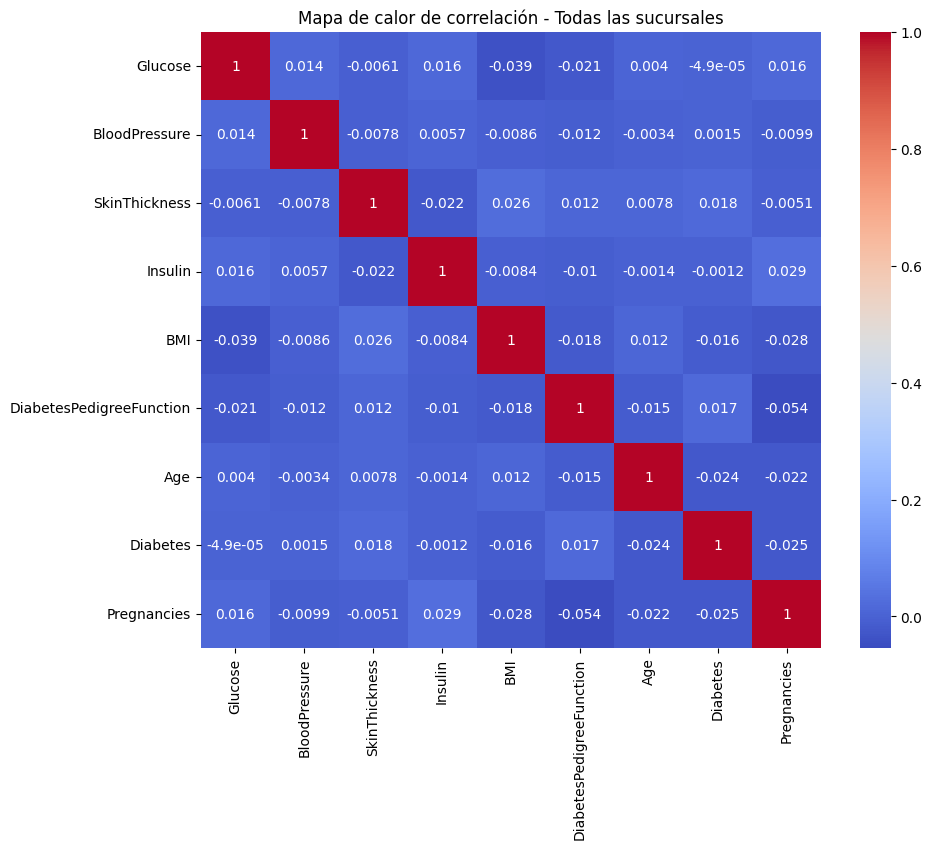

In [157]:
# Agregar columna de sucursal
XDB_Bello['Sucursal'] = 'Bello'
XDB_Medellin['Sucursal'] = 'Medellin'
XDB_Envigado['Sucursal'] = 'Envigado'
XDB_Caldas['Sucursal'] = 'Caldas'
XDB_Sabaneta['Sucursal'] = 'Sabaneta'
XDB_Itagui['Sucursal'] = 'Itagui'

# Unir todas las sucursales en un solo DataFrame
XDB_total = pd.concat([
    XDB_Bello,
    XDB_Medellin,
    XDB_Envigado,
    XDB_Caldas,
    XDB_Sabaneta,
    XDB_Itagui
], ignore_index=True)

# Graficar mapa de calor
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True)
plt.title('Mapa de calor de correlación - Todas las sucursales')
plt.show()

**3. Caracterización de las distribuciones de probabilidad**

Revisar cómo se comporta Glucose en cada sucursal.  

**3.1 Sucursal Sabaneta**

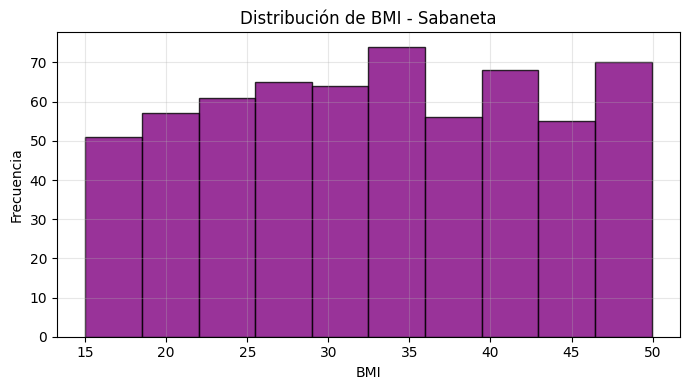

El número de datos por intervalo es:
[51 57 61 65 64 74 56 68 55 70]
Los intervalos inferiores son:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores son:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]

Media: 32.9658
Desviación estándar: 9.8379
Coeficiente de asimetría: -0.0257
Kurtosis: -1.1628


,LI,LS,XC,ND
0,15.0030,18.4971,16.75005,51.0
1,18.4971,21.9912,20.24415,57.0
2,21.9912,25.4853,23.73825,61.0
3,25.4853,28.9794,27.23235,65.0
4,28.9794,32.4735,30.72645,64.0
5,32.4735,35.9676,34.22055,74.0
6,35.9676,39.4617,37.71465,56.0
7,39.4617,42.9558,41.20875,68.0
8,42.9558,46.4499,44.70285,55.0
9,46.4499,49.9440,48.19695,70.0


In [158]:
# Se caracteriza la distribución de Sabaneta
u_sabaneta, sigma_sabaneta, Cas_sabaneta, Kur_sabaneta, df_sabaneta = caracterizacion(LDA_Sabaneta, 'Sabaneta')

**3.2 Sucursal Bello**

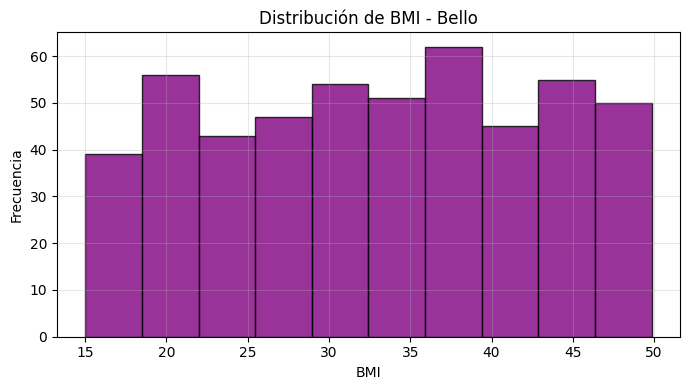

El número de datos por intervalo es:
[39 56 43 47 54 51 62 45 55 50]
Los intervalos inferiores son:
[15.003 18.488 21.973 25.458 28.943 32.428 35.913 39.398 42.883 46.368]
Los intervalos superiores son:
[18.488 21.973 25.458 28.943 32.428 35.913 39.398 42.883 46.368 49.853]

Media: 32.9278
Desviación estándar: 9.8044
Coeficiente de asimetría: -0.0599
Kurtosis: -1.1861


,LI,LS,XC,ND
0,15.003,18.488,16.7455,39.0
1,18.488,21.973,20.2305,56.0
2,21.973,25.458,23.7155,43.0
3,25.458,28.943,27.2005,47.0
4,28.943,32.428,30.6855,54.0
5,32.428,35.913,34.1705,51.0
6,35.913,39.398,37.6555,62.0
7,39.398,42.883,41.1405,45.0
8,42.883,46.368,44.6255,55.0
9,46.368,49.853,48.1105,50.0


In [159]:
# Se caracteriza la distribución de Bello
u_bello, sigma_bello, Cas_bello, Kur_bello, df_bello = caracterizacion(LDA_Bello, 'Bello')

**3.3 Sucursal Medellín**

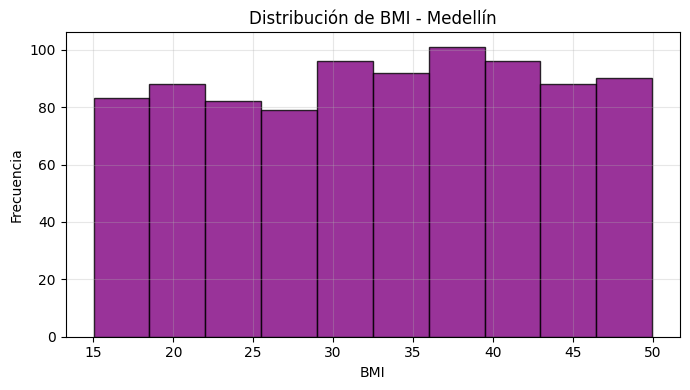

El número de datos por intervalo es:
[ 83  88  82  79  96  92 101  96  88  90]
Los intervalos inferiores son:
[15.008  18.5043 22.0006 25.4969 28.9932 32.4895 35.9858 39.4821 42.9784
 46.4747]
Los intervalos superiores son:
[18.5043 22.0006 25.4969 28.9932 32.4895 35.9858 39.4821 42.9784 46.4747
 49.971 ]

Media: 32.8704
Desviación estándar: 9.9257
Coeficiente de asimetría: -0.0697
Kurtosis: -1.1880


,LI,LS,XC,ND
0,15.0080,18.5043,16.75615,83.0
1,18.5043,22.0006,20.25245,88.0
2,22.0006,25.4969,23.74875,82.0
3,25.4969,28.9932,27.24505,79.0
4,28.9932,32.4895,30.74135,96.0
5,32.4895,35.9858,34.23765,92.0
6,35.9858,39.4821,37.73395,101.0
7,39.4821,42.9784,41.23025,96.0
8,42.9784,46.4747,44.72655,88.0
9,46.4747,49.9710,48.22285,90.0


In [160]:
# Se caracteriza la distribución de Medellín
u_medellin, sigma_medellin, Cas_medellin, Kur_medellin, df_medellin = caracterizacion(LDA_Medellin, 'Medellín')

**3.4 Sucursal Envigado**

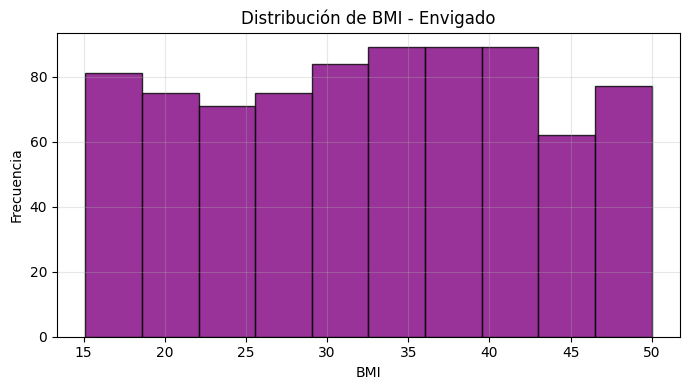

El número de datos por intervalo es:
[81 75 71 75 84 89 89 89 62 77]
Los intervalos inferiores son:
[15.096  18.5857 22.0754 25.5651 29.0548 32.5445 36.0342 39.5239 43.0136
 46.5033]
Los intervalos superiores son:
[18.5857 22.0754 25.5651 29.0548 32.5445 36.0342 39.5239 43.0136 46.5033
 49.993 ]

Media: 32.5665
Desviación estándar: 9.8344
Coeficiente de asimetría: -0.0402
Kurtosis: -1.1492


,LI,LS,XC,ND
0,15.0960,18.5857,16.84085,81.0
1,18.5857,22.0754,20.33055,75.0
2,22.0754,25.5651,23.82025,71.0
3,25.5651,29.0548,27.30995,75.0
4,29.0548,32.5445,30.79965,84.0
5,32.5445,36.0342,34.28935,89.0
6,36.0342,39.5239,37.77905,89.0
7,39.5239,43.0136,41.26875,89.0
8,43.0136,46.5033,44.75845,62.0
9,46.5033,49.9930,48.24815,77.0


In [161]:
# Se caracteriza la distribución de Envigado
u_envigado, sigma_envigado, Cas_envigado, Kur_envigado, df_envigado = caracterizacion(LDA_Envigado, 'Envigado')

**3.5 Sucursal Caldas**

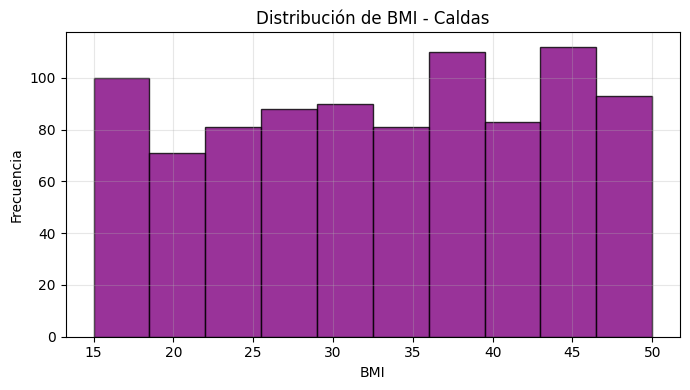

El número de datos por intervalo es:
[100  71  81  88  90  81 110  83 112  93]
Los intervalos inferiores son:
[15.     18.4985 21.997  25.4955 28.994  32.4925 35.991  39.4895 42.988
 46.4865]
Los intervalos superiores son:
[18.4985 21.997  25.4955 28.994  32.4925 35.991  39.4895 42.988  46.4865
 49.985 ]

Media: 33.0525
Desviación estándar: 10.1425
Coeficiente de asimetría: -0.1105
Kurtosis: -1.2182


,LI,LS,XC,ND
0,15.0000,18.4985,16.74925,100.0
1,18.4985,21.9970,20.24775,71.0
2,21.9970,25.4955,23.74625,81.0
3,25.4955,28.9940,27.24475,88.0
4,28.9940,32.4925,30.74325,90.0
5,32.4925,35.9910,34.24175,81.0
6,35.9910,39.4895,37.74025,110.0
7,39.4895,42.9880,41.23875,83.0
8,42.9880,46.4865,44.73725,112.0
9,46.4865,49.9850,48.23575,93.0


In [162]:
# Se caracteriza la distribución de Caldas
u_caldas, sigma_caldas, Cas_caldas, Kur_caldas, df_caldas = caracterizacion(LDA_Caldas, 'Caldas')

**3.6 Sucursal Itagüí**

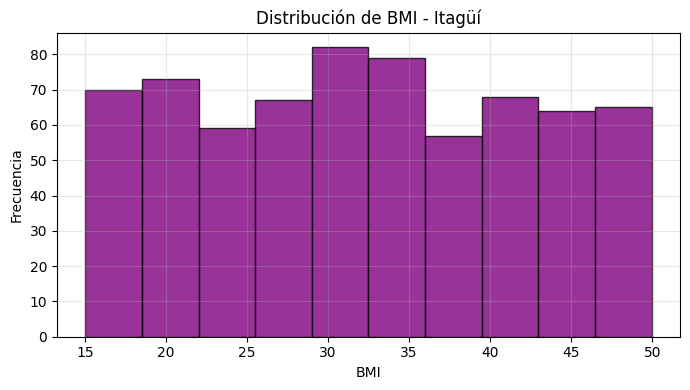

El número de datos por intervalo es:
[70 73 59 67 82 79 57 68 64 65]
Los intervalos inferiores son:
[15.019  18.5136 22.0082 25.5028 28.9974 32.492  35.9866 39.4812 42.9758
 46.4704]
Los intervalos superiores son:
[18.5136 22.0082 25.5028 28.9974 32.492  35.9866 39.4812 42.9758 46.4704
 49.965 ]

Media: 32.2468
Desviación estándar: 9.9289
Coeficiente de asimetría: 0.0273
Kurtosis: -1.1722


,LI,LS,XC,ND
0,15.0190,18.5136,16.7663,70.0
1,18.5136,22.0082,20.2609,73.0
2,22.0082,25.5028,23.7555,59.0
3,25.5028,28.9974,27.2501,67.0
4,28.9974,32.4920,30.7447,82.0
5,32.4920,35.9866,34.2393,79.0
6,35.9866,39.4812,37.7339,57.0
7,39.4812,42.9758,41.2285,68.0
8,42.9758,46.4704,44.7231,64.0
9,46.4704,49.9650,48.2177,65.0


In [163]:
# Se caracteriza la distribución de Itagüí
u_itagui, sigma_itagui, Cas_itagui, Kur_itagui, df_itagui = caracterizacion(LDA_Itagui, 'Itagüí')

**4. Medidas de tendencia central antes de la integración**



In [164]:
resumen_inicial = pd.DataFrame({
    'Sucursal': ['Sabaneta', 'Bello', 'Medellín', 'Envigado', 'Caldas', 'Itagui'],
    'Número de datos': [len(LDA_Sabaneta), len(LDA_Bello), len(LDA_Medellin), len(LDA_Envigado), len(LDA_Caldas), len(LDA_Itagui)],
    'Media': [u_sabaneta, u_bello, u_medellin, u_envigado, u_caldas, u_itagui],
    'Sigma': [sigma_sabaneta, sigma_bello, sigma_medellin, sigma_envigado, sigma_caldas, sigma_itagui],
    'Asimetría': [Cas_sabaneta, Cas_bello, Cas_medellin, Cas_envigado, Cas_caldas, Cas_itagui],
    'Kurtosis': [Kur_sabaneta, Kur_bello, Kur_medellin, Kur_envigado, Kur_caldas, Kur_itagui]
})

display(resumen_inicial.round(4))

,Sucursal,Número de datos,Media,Sigma,Asimetría,Kurtosis
0,Sabaneta,621,32.9658,9.8379,-0.0257,-1.1628
1,Bello,502,32.9278,9.8044,-0.0599,-1.1861
2,Medellín,895,32.8704,9.9257,-0.0697,-1.1880
3,Envigado,792,32.5665,9.8344,-0.0402,-1.1492
4,Caldas,909,33.0525,10.1425,-0.1105,-1.2182
5,Itagui,684,32.2468,9.9289,0.0273,-1.1722


**5. Teoría de la credibilidad**

Se compara la sucursal de Sabaneta con cada una de las sedes. Se estima qué tan parecida es Sabaneta a cada sucursal usando:

- EPV: valor esperado de la varianza
- VHM: valor hipotético de la media
- fc: factor de credibilidad
- Cr: credibilidad final

La sucursal que tenga la credibilidad más alta será la mejor candidata para recibir a los pacientes de Sabaneta.

In [165]:
# Se definen los tamaños de muestra
N_Sabaneta = len(LDA_Sabaneta)
N_Bello = len(LDA_Bello)
N_Medellin = len(LDA_Medellin)
N_Envigado = len(LDA_Envigado)
N_Caldas = len(LDA_Caldas)
N_Itagui = len(LDA_Itagui)

# Se almacenan las sucursales externas
Sucursales = {
    'Bello': (u_bello, sigma_bello, N_Bello),
    'Medellín': (u_medellin, sigma_medellin, N_Medellin),
    'Envigado': (u_envigado, sigma_envigado, N_Envigado),
    'Caldas': (u_caldas, sigma_caldas, N_Caldas),
    'Itagui': (u_itagui, sigma_itagui, N_Itagui)
}

credibilidad = {}
detalle_credibilidad = []

for nombre, (ue, sigmae, NDe) in Sucursales.items():

  # Se procede con el Valor Esperado de la Varianza (EPV)
  EPV = (sigma_sabaneta * N_Sabaneta + sigmae * NDe) / (N_Sabaneta + NDe)

  # Se procede con la estimación del Valor Hipotético de la Media (VHM)
  uh = (u_sabaneta * N_Sabaneta + ue * NDe) / (N_Sabaneta + NDe)
  VHM = ((N_Sabaneta * u_sabaneta ** 2 + NDe * ue ** 2) / (N_Sabaneta + NDe)) - uh ** 2

  # Se procede con la estimación del factor de credibilidad (fc)
  fc = EPV / VHM

  # Se procede con la estimación de la credibilidad
  Cr = N_Sabaneta / (N_Sabaneta + fc)

  credibilidad[nombre] = Cr
  detalle_credibilidad.append([nombre, EPV, VHM, fc, Cr])

  print(f"\nSabaneta vs {nombre}")
  print(f"Media Sabaneta: {u_sabaneta:.4f}")
  print(f"Media {nombre}: {ue:.4f}")
  print(f"EPV: {EPV:.4f}")
  print(f"VHM: {VHM:.4f}")
  print(f"Factor de Credibilidad (fc): {fc:.4f}")
  print(f"Credibilidad (Cr): {Cr:.4f} ({Cr*100:.2f}%)")

tabla_credibilidad = pd.DataFrame(detalle_credibilidad, columns=['Sucursal', 'EPV', 'VHM', 'fc', 'Cr'])
display(tabla_credibilidad.round(4))


Sabaneta vs Bello
Media Sabaneta: 32.9658
Media Bello: 32.9278
EPV: 9.8229
VHM: 0.0004
Factor de Credibilidad (fc): 27542.0779
Credibilidad (Cr): 0.0221 (2.21%)

Sabaneta vs Medellín
Media Sabaneta: 32.9658
Media Medellín: 32.8704
EPV: 9.8897
VHM: 0.0022
Factor de Credibilidad (fc): 4489.2941
Credibilidad (Cr): 0.1215 (12.15%)

Sabaneta vs Envigado
Media Sabaneta: 32.9658
Media Envigado: 32.5665
EPV: 9.8359
VHM: 0.0393
Factor de Credibilidad (fc): 250.4369
Credibilidad (Cr): 0.7126 (71.26%)

Sabaneta vs Caldas
Media Sabaneta: 32.9658
Media Caldas: 33.0525
EPV: 10.0189
VHM: 0.0018
Factor de Credibilidad (fc): 5531.5622
Credibilidad (Cr): 0.1009 (10.09%)

Sabaneta vs Itagui
Media Sabaneta: 32.9658
Media Itagui: 32.2468
EPV: 9.8856
VHM: 0.1290
Factor de Credibilidad (fc): 76.6560
Credibilidad (Cr): 0.8901 (89.01%)


,Sucursal,EPV,VHM,fc,Cr
0,Bello,9.8229,0.0004,27542.0779,0.0221
1,Medellín,9.8897,0.0022,4489.2941,0.1215
2,Envigado,9.8359,0.0393,250.4369,0.7126
3,Caldas,10.0189,0.0018,5531.5622,0.1009
4,Itagui,9.8856,0.1290,76.6560,0.8901


In [166]:
# Se identifica la sucursal con mayor afinidad
mejor_sucursal = min(credibilidad, key=credibilidad.get)
mejor_Cr = credibilidad[mejor_sucursal]

print("Resultado de Credibilidades")
for nombre, Cr in credibilidad.items():
    print(f"{nombre}: {Cr*100:.2f}%")

print(f"\nLa sucursal con mayor afinidad con Sabaneta es: {mejor_sucursal} con una credibilidad del {mejor_Cr*100:.2f}%")

Resultado de Credibilidades
Bello: 2.21%
Medellín: 12.15%
Envigado: 71.26%
Caldas: 10.09%
Itagui: 89.01%

La sucursal con mayor afinidad con Sabaneta es: Bello con una credibilidad del 2.21%


**6. Selección de la sucursal destino**

**Análisis de credibilidad**

Con esta comparación se busca encontrar la sede cuyo comportamiento en la variable BMI sea más parecido al de Sabaneta.  La sucursal seleccionada será la que reciba la integración, porque en principio debería generar un menor cambio en la distribución de los pacientes después del traslado.

In [167]:
# Se selecciona la sucursal destino con mayor credibilidad
# Los datos internos corresponden a la sucursal destino
# Los datos externos corresponden a la sucursal de Sabaneta

if mejor_sucursal == 'Bello':
    LDA_destino = np.copy(LDA_Bello)
    u_destino = u_bello; sigma_destino = sigma_bello
elif mejor_sucursal == 'Medellín':
    LDA_destino = np.copy(LDA_Medellin)
    u_destino = u_medellin; sigma_destino = sigma_medellin
elif mejor_sucursal == 'Envigado':
    LDA_destino = np.copy(LDA_Envigado)
    u_destino = u_envigado; sigma_destino = sigma_envigado
elif mejor_sucursal == 'Caldas':
    LDA_destino = np.copy(LDA_Caldas)
    u_destino = u_caldas; sigma_destino = sigma_caldas
elif mejor_sucursal == 'Itagui':
    LDA_destino = np.copy(LDA_Itagui)
    u_destino = u_itagui; sigma_destino = sigma_itagui

print(f"Sucursal destino: {mejor_sucursal}")
print(f"Media destino: {u_destino:.4f}")
print(f"Sigma destino: {sigma_destino:.4f}")
print(f"Datos internos (destino): {len(LDA_destino)}")
print(f"Datos externos (Sabaneta): {len(LDA_Sabaneta)}")

# También se guardan la asimetría y la kurtosis de la sede destino
if mejor_sucursal == 'Bello':
    Cas_destino = Cas_bello; Kur_destino = Kur_bello
elif mejor_sucursal == 'Medellín':
    Cas_destino = Cas_medellin; Kur_destino = Kur_medellin
elif mejor_sucursal == 'Envigado':
    Cas_destino = Cas_envigado; Kur_destino = Kur_envigado
elif mejor_sucursal == 'Caldas':
    Cas_destino = Cas_caldas; Kur_destino = Kur_caldas
elif mejor_sucursal == 'Itagui':
    Cas_destino = Cas_itagui; Kur_destino = Kur_itagui


Sucursal destino: Bello
Media destino: 32.9278
Sigma destino: 9.8044
Datos internos (destino): 502
Datos externos (Sabaneta): 621


 **7. Integración por valor de pertenencia**

Se calcula el valor de pertenencia de cada paciente de Sabaneta respecto a la distribución de la sucursal destino.  Se integran solamente los datos cuyo valor de pertenencia sea mayor a 0.9.

In [168]:
# Se integran los datos de Sabaneta cuyo valor de pertenencia sea mayor a 0.9

LDAint1 = np.copy(LDA_destino)
LDA_ext = np.array(LDA_Sabaneta)

m1 = 0
vp_lista = []

for k in range(len(LDA_ext)):
    VP = np.exp(-0.5 * ((u_destino - LDA_ext[k]) / sigma_destino) ** 2)
    vp_lista.append(VP)

    if VP > 0.9:
        m1 = m1 + 1
        LDAint1 = np.append(LDAint1, LDA_ext[k])

print(f"Datos de Sabaneta integrados (Método I): {m1} de {len(LDA_ext)}")
print(f"Total de datos después de integración: {len(LDAint1)}")

Datos de Sabaneta integrados (Método I): 177 de 621
Total de datos después de integración: 679


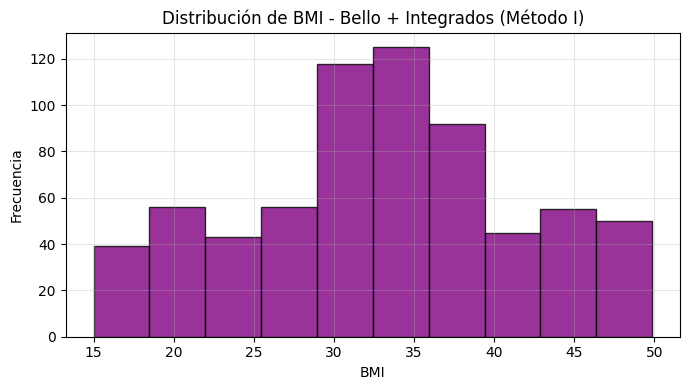

El número de datos por intervalo es:
[ 39  56  43  56 118 125  92  45  55  50]
Los intervalos inferiores son:
[15.003 18.488 21.973 25.458 28.943 32.428 35.913 39.398 42.883 46.368]
Los intervalos superiores son:
[18.488 21.973 25.458 28.943 32.428 35.913 39.398 42.883 46.368 49.853]

Media: 32.9849
Desviación estándar: 8.5516
Coeficiente de asimetría: -0.0847
Kurtosis: -0.6736


,LI,LS,XC,ND
0,15.003,18.488,16.7455,39.0
1,18.488,21.973,20.2305,56.0
2,21.973,25.458,23.7155,43.0
3,25.458,28.943,27.2005,56.0
4,28.943,32.428,30.6855,118.0
5,32.428,35.913,34.1705,125.0
6,35.913,39.398,37.6555,92.0
7,39.398,42.883,41.1405,45.0
8,42.883,46.368,44.6255,55.0
9,46.368,49.853,48.1105,50.0



''''''''''''''''''''''''''''''''''''''''''''''''''
Media datos destino (Bello) ANTES: 32.9278
Media datos integrados DESPUÉS: 32.9849
Discrepancia entre las medias: 0.1732%

Sigma datos destino (Bello) ANTES: 9.8044
Sigma datos integrados DESPUÉS: 8.5516
Discrepancia entre las sigmas: 12.7781%


In [169]:
# Se validan las propiedades estadísticas después de la integración
ui1, sigmai1, Casi1, Kuri1, dfi1 = caracterizacion(LDAint1, f"{mejor_sucursal} + Integrados (Método I)")

print("\n" + "'" * 50)
print(f"Media datos destino ({mejor_sucursal}) ANTES: {u_destino:.4f}")
print(f"Media datos integrados DESPUÉS: {ui1:.4f}")
disc_u1 = np.abs((u_destino - ui1) / u_destino) * 100
print(f"Discrepancia entre las medias: {disc_u1:.4f}%")

print(f"\nSigma datos destino ({mejor_sucursal}) ANTES: {sigma_destino:.4f}")
print(f"Sigma datos integrados DESPUÉS: {sigmai1:.4f}")
disc_s1 = np.abs((sigma_destino - sigmai1) / sigma_destino) * 100
print(f"Discrepancia entre las sigmas: {disc_s1:.4f}%")

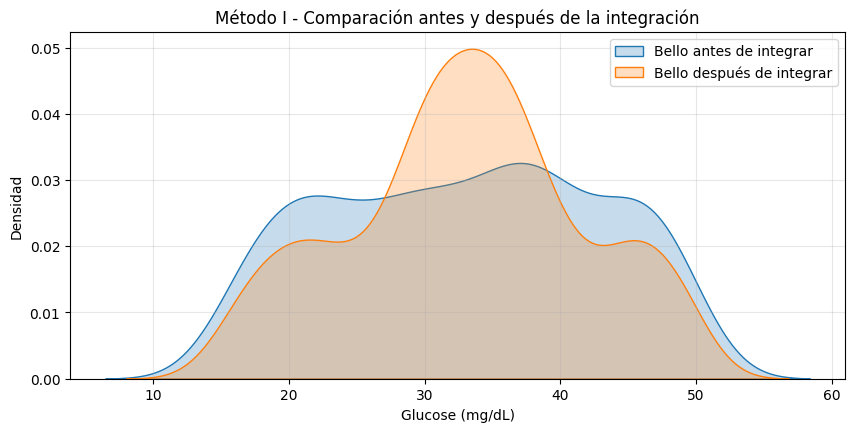

In [170]:
# Se compara visualmente la distribución antes y después de la integración por valor de pertenencia
plt.figure(figsize=(10, 4.5))
sns.kdeplot(LDA_destino, label=f'{mejor_sucursal} antes de integrar', fill=True, alpha=0.25)
sns.kdeplot(LDAint1, label=f'{mejor_sucursal} después de integrar', fill=True, alpha=0.25)
plt.title('Método I - Comparación antes y después de la integración')
plt.xlabel('Glucose (mg/dL)')
plt.ylabel('Densidad')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**8. Integración por aceptación y rechazo**

- VPo: qué tan parecido es el dato de Sabaneta a la sucursal destino
- VPe: qué tan parecido es el dato a la propia distribución de Sabaneta

Si VPo > VPe, el dato se integra.

In [171]:
# Método II: Aceptación/Rechazo
# Se comparan los valores de pertenencia internos y externos

LDAint2 = np.copy(LDA_destino)

m2 = 0
for k in range(len(LDA_ext)):
    VPo = np.exp(-0.5 * ((u_destino - LDA_ext[k]) / sigma_destino) ** 2)
    VPe = np.exp(-0.5 * ((u_sabaneta - LDA_ext[k]) / sigma_sabaneta) ** 2)

    if VPo > VPe:
        m2 = m2 + 1
        LDAint2 = np.append(LDAint2, LDA_ext[k])

print(f"Datos de Sabaneta integrados (Método II): {m2} de {len(LDA_ext)}")
print(f"Total de datos después de integración: {len(LDAint2)}")

Datos de Sabaneta integrados (Método II): 207 de 621
Total de datos después de integración: 709


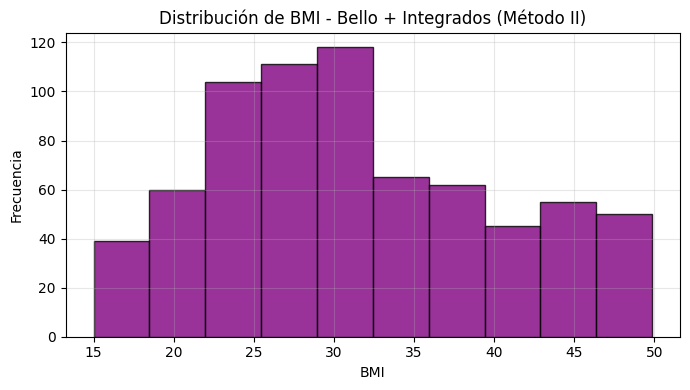

El número de datos por intervalo es:
[ 39  60 104 111 118  65  62  45  55  50]
Los intervalos inferiores son:
[15.003 18.488 21.973 25.458 28.943 32.428 35.913 39.398 42.883 46.368]
Los intervalos superiores son:
[18.488 21.973 25.458 28.943 32.428 35.913 39.398 42.883 46.368 49.853]

Media: 31.3687
Desviación estándar: 8.7913
Coeficiente de asimetría: 0.3363
Kurtosis: -0.8194


,LI,LS,XC,ND
0,15.003,18.488,16.7455,39.0
1,18.488,21.973,20.2305,60.0
2,21.973,25.458,23.7155,104.0
3,25.458,28.943,27.2005,111.0
4,28.943,32.428,30.6855,118.0
5,32.428,35.913,34.1705,65.0
6,35.913,39.398,37.6555,62.0
7,39.398,42.883,41.1405,45.0
8,42.883,46.368,44.6255,55.0
9,46.368,49.853,48.1105,50.0



''''''''''''''''''''''''''''''''''''''''''''''''''
Media datos destino (Bello) ANTES: 32.9278
Media datos integrados DESPUÉS: 31.3687
Discrepancia entre las medias: 4.7349%

Sigma datos destino (Bello) ANTES: 9.8044
Sigma datos integrados DESPUÉS: 8.7913
Discrepancia entre las sigmas: 10.3330%


In [172]:
# Se validan las propiedades estadísticas después de la integración
ui2, sigmai2, Casi2, Kuri2, dfi2 = caracterizacion(LDAint2, f"{mejor_sucursal} + Integrados (Método II)")

print("\n" + "'" * 50)
print(f"Media datos destino ({mejor_sucursal}) ANTES: {u_destino:.4f}")
print(f"Media datos integrados DESPUÉS: {ui2:.4f}")
disc_u2 = np.abs((u_destino - ui2) / u_destino) * 100
print(f"Discrepancia entre las medias: {disc_u2:.4f}%")

print(f"\nSigma datos destino ({mejor_sucursal}) ANTES: {sigma_destino:.4f}")
print(f"Sigma datos integrados DESPUÉS: {sigmai2:.4f}")
disc_s2 = np.abs((sigma_destino - sigmai2) / sigma_destino) * 100
print(f"Discrepancia entre las sigmas: {disc_s2:.4f}%")

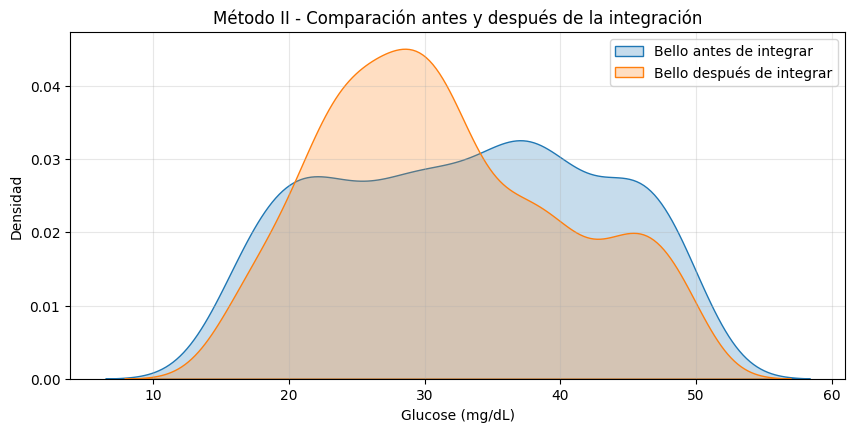

In [173]:
# Se compara visualmente la distribución antes y después de la integración por aceptación y rechazo
plt.figure(figsize=(10, 4.5))
sns.kdeplot(LDA_destino, label=f'{mejor_sucursal} antes de integrar', fill=True, alpha=0.25)
sns.kdeplot(LDAint2, label=f'{mejor_sucursal} después de integrar', fill=True, alpha=0.25)
plt.title('Método II - Comparación antes y después de la integración')
plt.xlabel('Glucose (mg/dL)')
plt.ylabel('Densidad')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**9. Integración por aceptación y rechazo con componente aleatorio**

In [174]:
# Método III: Aceptación/Rechazo con componente aleatorio
# Se fija semilla para que el resultado sea reproducible

np.random.seed(42)

LDAint3 = np.copy(LDA_destino)

m3 = 0
for k in range(len(LDA_ext)):
    VPo = np.exp(-0.5 * ((u_destino - LDA_ext[k]) / sigma_destino) ** 2)
    VPe = np.exp(-0.5 * ((u_sabaneta - LDA_ext[k]) / sigma_sabaneta) ** 2)
    aleatorio = np.random.rand()

    if VPo / VPe > aleatorio:
        m3 = m3 + 1
        LDAint3 = np.append(LDAint3, LDA_ext[k])

print(f"Datos de Sabaneta integrados (Método III): {m3} de {len(LDA_ext)}")
print(f"Total de datos después de integración: {len(LDAint3)}")

Datos de Sabaneta integrados (Método III): 618 de 621
Total de datos después de integración: 1120


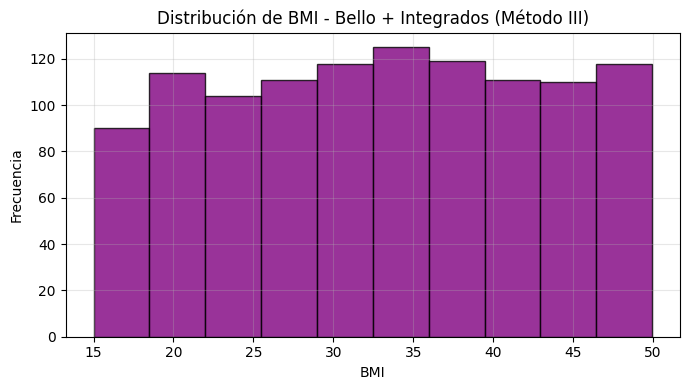

El número de datos por intervalo es:
[ 90 114 104 111 118 125 119 111 110 118]
Los intervalos inferiores son:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores son:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]

Media: 32.9259
Desviación estándar: 9.8271
Coeficiente de asimetría: -0.0372
Kurtosis: -1.1724


,LI,LS,XC,ND
0,15.0030,18.4971,16.75005,90.0
1,18.4971,21.9912,20.24415,114.0
2,21.9912,25.4853,23.73825,104.0
3,25.4853,28.9794,27.23235,111.0
4,28.9794,32.4735,30.72645,118.0
5,32.4735,35.9676,34.22055,125.0
6,35.9676,39.4617,37.71465,119.0
7,39.4617,42.9558,41.20875,111.0
8,42.9558,46.4499,44.70285,110.0
9,46.4499,49.9440,48.19695,118.0



''''''''''''''''''''''''''''''''''''''''''''''''''
Media datos destino (Bello) ANTES: 32.9278
Media datos integrados DESPUÉS: 32.9259
Discrepancia entre las medias: 0.0060%

Sigma datos destino (Bello) ANTES: 9.8044
Sigma datos integrados DESPUÉS: 9.8271
Discrepancia entre las sigmas: 0.2316%


In [175]:
# Se validan las propiedades estadísticas después de la integración
ui3, sigmai3, Casi3, Kuri3, dfi3 = caracterizacion(LDAint3, f"{mejor_sucursal} + Integrados (Método III)")

print("\n" + "'" * 50)
print(f"Media datos destino ({mejor_sucursal}) ANTES: {u_destino:.4f}")
print(f"Media datos integrados DESPUÉS: {ui3:.4f}")
disc_u3 = np.abs((u_destino - ui3) / u_destino) * 100
print(f"Discrepancia entre las medias: {disc_u3:.4f}%")

print(f"\nSigma datos destino ({mejor_sucursal}) ANTES: {sigma_destino:.4f}")
print(f"Sigma datos integrados DESPUÉS: {sigmai3:.4f}")
disc_s3 = np.abs((sigma_destino - sigmai3) / sigma_destino) * 100
print(f"Discrepancia entre las sigmas: {disc_s3:.4f}%")

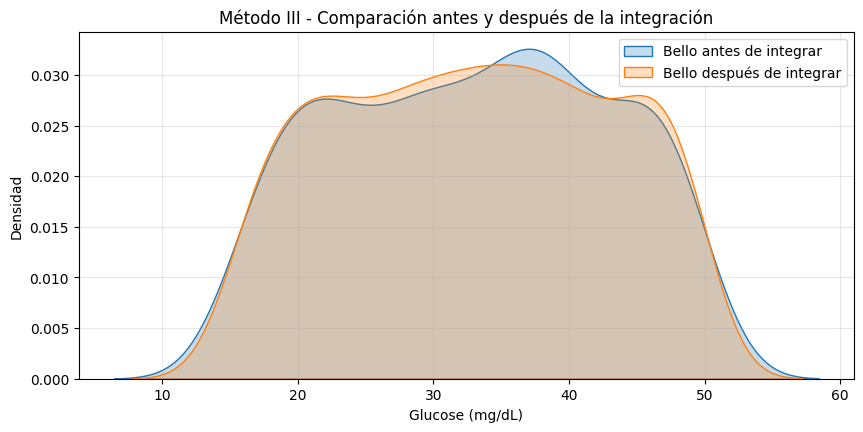

In [176]:
# Se compara visualmente la distribución antes y después de la integración con componente aleatorio
plt.figure(figsize=(10, 4.5))
sns.kdeplot(LDA_destino, label=f'{mejor_sucursal} antes de integrar', fill=True, alpha=0.25)
sns.kdeplot(LDAint3, label= f'{mejor_sucursal} después de integrar', fill=True, alpha=0.25)
plt.title('Método III - Comparación antes y después de la integración')
plt.xlabel('Glucose (mg/dL)')
plt.ylabel('Densidad')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

 **10. Comparación de los métodos de integración**

In [177]:
# Se construye la tabla comparativa
resumen_final = pd.DataFrame({
    'Métrica': ['Número de datos', 'Datos integrados', 'Media', 'Sigma', 'Asimetría', 'Kurtosis', 'Discrepancia media (%)', 'Discrepancia sigma (%)'],
    'Antes': [len(LDA_destino), '-', u_destino, sigma_destino, Cas_destino, Kur_destino, '-', '-'],
    'Método I': [len(LDAint1), m1, ui1, sigmai1, Casi1, Kuri1, disc_u1, disc_s1],
    'Método II': [len(LDAint2), m2, ui2, sigmai2, Casi2, Kuri2, disc_u2, disc_s2],
    'Método III': [len(LDAint3), m3, ui3, sigmai3, Casi3, Kuri3, disc_u3, disc_s3]
})

display(resumen_final)

,Métrica,Antes,Método I,Método II,Método III
0,Número de datos,502,679.000000,709.000000,1120.000000
1,Datos integrados,-,177.000000,207.000000,618.000000
2,Media,32.927841,32.984881,31.368737,32.925861
3,Sigma,9.80437,8.551558,8.791280,9.827075
4,Asimetría,-0.059945,-0.084683,0.336345,-0.037166
5,Kurtosis,-1.186052,-0.673557,-0.819366,-1.172384
6,Discrepancia media (%),-,0.173230,4.734910,0.006012
7,Discrepancia sigma (%),-,12.778096,10.333039,0.231579


In [178]:
# Se construye una tabla para hacer la comparación del antes y el después
comparacion_estadistica = pd.DataFrame({
    'Escenario': [
        f'{mejor_sucursal} antes de integrar',
        'Después del Método I',
        'Después del Método II',
        'Después del Método III'
    ],
    'Número de datos': [len(LDA_destino), len(LDAint1), len(LDAint2), len(LDAint3)],
    'Media': [u_destino, ui1, ui2, ui3],
    'Sigma': [sigma_destino, sigmai1, sigmai2, sigmai3],
    'Asimetría': [Cas_destino, Casi1, Casi2, Casi3],
    'Kurtosis': [Kur_destino, Kuri1, Kuri2, Kuri3]
})

display(comparacion_estadistica.round(4))

,Escenario,Número de datos,Media,Sigma,Asimetría,Kurtosis
0,Bello antes de integrar,502,32.9278,9.8044,-0.0599,-1.1861
1,Después del Método I,679,32.9849,8.5516,-0.0847,-0.6736
2,Después del Método II,709,31.3687,8.7913,0.3363,-0.8194
3,Después del Método III,1120,32.9259,9.8271,-0.0372,-1.1724


**Análisis de Resultados**

La sede de Sabaneta fue utilizada como punto de referencia para evaluar la compatibilidad estadística con las demás sucursales de la EPS. Los valores de credibilidad permiten identificar qué tan similares son las distribuciones de datos entre las distintas sedes y estimar cuáles tienen mayor capacidad para recibir pacientes sin generar alteraciones significativas.

* Bello presentó el menor nivel de discrepancia (0.022), lo que indica que sus datos mantienen una estructura muy similar a la de Sabaneta. Esto sugiere que esta sede sería una de las más adecuadas para realizar procesos de integración o traslado de pacientes.

* Sedes como Envigado e Itagüí, con un valor de 0.71 y 0.89 respectivamente, muestran una mayor diferencia en la distribución de los datos. Esto implica que una integración de pacientes que podría generar cambios más notorios.

El análisis de credibilidad permite identificar las sedes con mayor compatibilidad estadística, facilitando la toma de decisiones sobre la redistribución de pacientes dentro de la EPS, priorizando aquellas sucursales que presentan menores discrepancias y mayor estabilidad en sus distribuciones de datos.